In [8]:
%pip install pyodbc

     ---------------------------------------- 0.0/69.4 kB ? eta -:--:--
     ---------------------------------------- 69.4/69.4 kB ? eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [9]:
#Importar librerias:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pyodbc

In [16]:
# 1.Carga de datos:
# Configuración de la conexión
server = 'DESKTOP-IJ7B91L\SQLEXPRESS' # Puede ser localhost o el nombre de tu PC
database = 'PruebaCSV'

# String de conexión usando Autenticación de Windows
conn_str = f'DRIVER={{SQL Server}};SERVER={server};DATABASE={database};Trusted_Connection=yes;'

conn = pyodbc.connect(conn_str)

In [36]:
# 2. LLamamos a nuestra ultima vista en SQL:
# Usamos la vista que creaste para no repetir lógica en Python
# %%
query = "SELECT * FROM vista_analisis_riesgo"
df = pd.read_sql(query, conn)
conn.close()  # Cerramos la conexión apenas terminamos de leer

C:\Users\TEILS\AppData\Local\Temp\ipykernel_9816\173712222.py:5: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


In [37]:
print("Shape del dataframe:", df.shape)
print(df.head())

Shape del dataframe: (1000, 10)
  edad    sexo              tipo_trabajo vivienda     ahorros  \
0   67    male               Cualificado      own  Sin cuenta   
1   22  female               Cualificado      own      little   
2   49    male  No cualificado/Residente      own      little   
3   45    male               Cualificado     free      little   
4   53    male               Cualificado     free      little   

  cuenta_corriente monto_credito duracion_meses            proposito  \
0           little          1169              6             radio/TV   
1         moderate          5951             48             radio/TV   
2       Sin cuenta          2096             12            education   
3           little          7882             42  furniture/equipment   
4           little          4870             24                  car   

  categoria_riesgo  
0      Riesgo Bajo  
1      Riesgo Alto  
2      Riesgo Bajo  
3      Riesgo Alto  
4     Riesgo Medio  


In [ ]:
# 3. Conversion de tipos de datos:
# Aseguramos que las columnas clave sean numéricas (float o int)
cols_numericas = ['edad', 'monto_credito', 'duracion_meses']
for col in cols_numericas:
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [ ]:
# 4.1 Crear riesgo_num ANTES de usarlo en dropna
riesgo_map = {'Riesgo Bajo': 1, 'Riesgo Medio': 2, 'Riesgo Alto': 3}
df['riesgo_num'] = df['categoria_riesgo'].map(riesgo_map)

In [40]:
# 4.2 Eliminar nulos (ahora riesgo_num ya existe)
df_limpio = df.dropna(subset=cols_numericas + ['riesgo_num']).copy()
 
print("\nNulos en df_limpio (debe ser 0):")
print(df_limpio[cols_numericas + ['riesgo_num']].isnull().sum())


Nulos en df_limpio (debe ser 0):
edad              0
monto_credito     0
duracion_meses    0
riesgo_num        0
dtype: int64


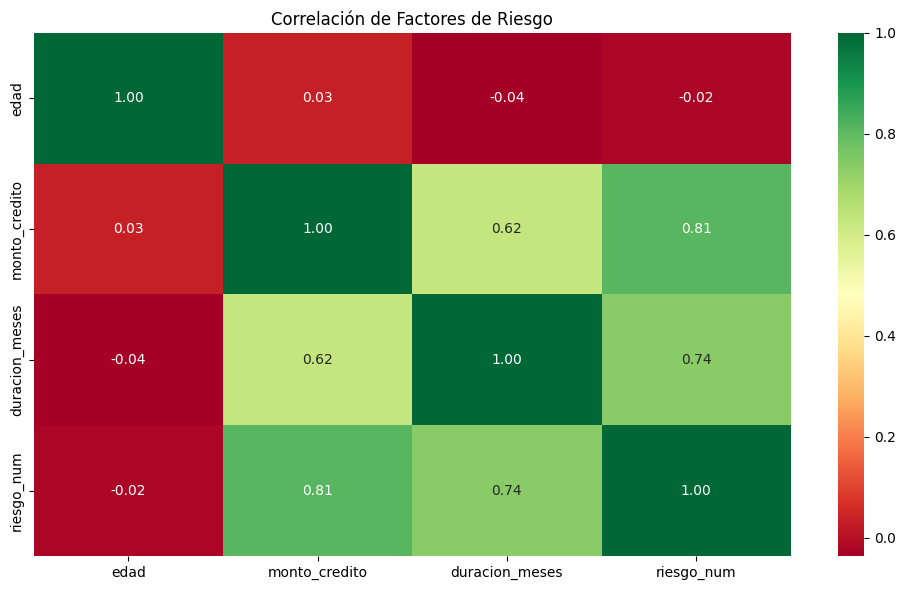

In [41]:
# 5.1 Mapa de Calor de Correlación
plt.figure(figsize=(10, 6))
sns.heatmap(
    df_limpio.select_dtypes(include=['number']).corr(),
    annot=True, cmap='RdYlGn', fmt='.2f'
)
plt.title('Correlación de Factores de Riesgo')
plt.tight_layout()
plt.show()

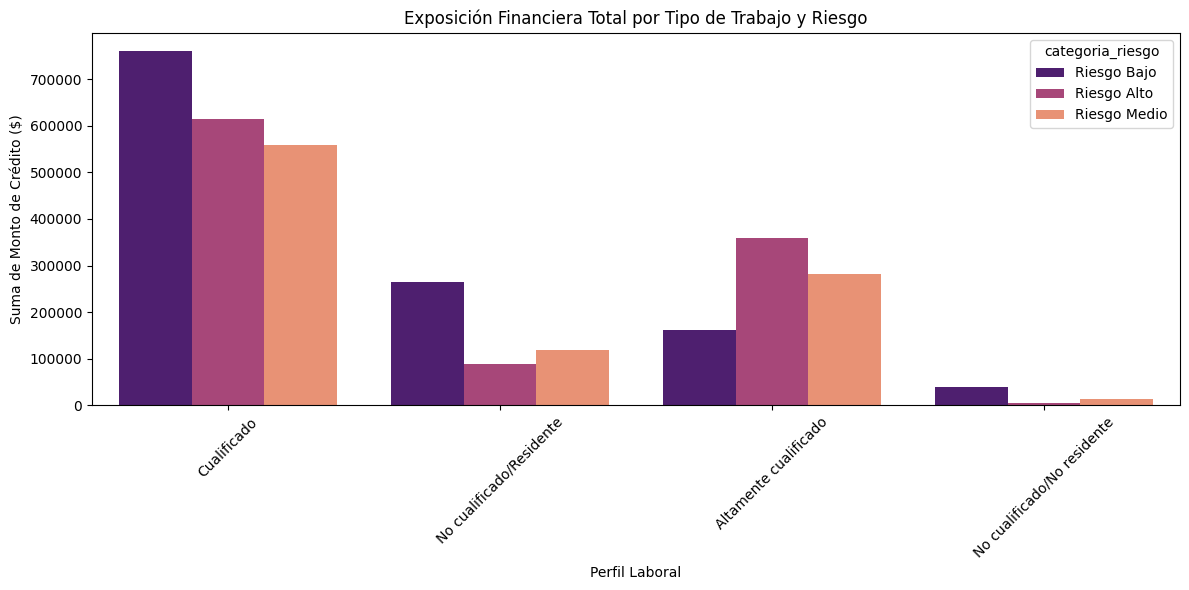

In [42]:
# 5.2 Exposición Financiera por Tipo de Trabajo
plt.figure(figsize=(12, 6))
sns.barplot(
    data=df_limpio,
    x='tipo_trabajo',
    y='monto_credito',
    hue='categoria_riesgo',
    estimator=sum,
    errorbar=None,
    palette='magma'
)
plt.title('Exposición Financiera Total por Tipo de Trabajo y Riesgo')
plt.ylabel('Suma de Monto de Crédito ($)')
plt.xlabel('Perfil Laboral')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [43]:
# --- 6. DETECCIÓN DE OUTLIERS (IQR) ---
Q1 = df_limpio['monto_credito'].quantile(0.25)
Q3 = df_limpio['monto_credito'].quantile(0.75)
IQR = Q3 - Q1
limite_superior = Q3 + 1.5 * IQR
 
outliers = df_limpio[df_limpio['monto_credito'] > limite_superior]
print(f"Créditos anómalos detectados: {len(outliers)}")
print(outliers[['edad', 'tipo_trabajo', 'monto_credito', 'categoria_riesgo']].head())

Créditos anómalos detectados: 72
    edad              tipo_trabajo  monto_credito categoria_riesgo
5     35  No cualificado/Residente           9055      Riesgo Alto
17    25               Cualificado           8072      Riesgo Alto
18    44     Altamente cualificado          12579     Riesgo Medio
57    31               Cualificado           9566      Riesgo Alto
63    25               Cualificado          14421      Riesgo Alto


In [54]:
#  7.Preparacion para Machine Learning:
#Importando librerias:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

# Trabajamos siempre sobre df_limpio (no sobre df original)
df_ml = df_limpio.copy()


In [55]:
# Encoder separado por columna para poder reutilizarlos luego
cols_categoricas = ['sexo', 'tipo_trabajo', 'proposito', 'ahorros']
encoders = {}
for col in cols_categoricas:
    encoders[col] = LabelEncoder()
    df_ml[col] = encoders[col].fit_transform(df_ml[col].astype(str))

In [56]:

# 8.Definiendo Features y Target:
features = ['edad', 'monto_credito', 'duracion_meses', 'tipo_trabajo']
target = 'categoria_riesgo'
 
X = df_ml[features]
y = df_ml[target]
 
print("Distribución de clases:")
print(y.value_counts())

Distribución de clases:
categoria_riesgo
Riesgo Bajo     666
Riesgo Medio    210
Riesgo Alto     124
Name: count, dtype: int64


In [57]:
# 9.SPLIT TRAIN / TEST 
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,    # Para reproducibilidad
    stratify=y          # Mantiene proporción de clases en ambos splits
)
 
print(f"Train: {len(X_train)} filas | Test: {len(X_test)} filas")

Train: 800 filas | Test: 200 filas


In [58]:
# 10.Entrenando el Modelo:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [59]:
# 11.Evaluando el Modelo:
y_pred = model.predict(X_test)
 
print(f"Precisión (accuracy): {model.score(X_test, y_test):.2f}\n")
print("Reporte completo por clase:")
print(classification_report(y_test, y_pred))

Precisión (accuracy): 0.99

Reporte completo por clase:
              precision    recall  f1-score   support

 Riesgo Alto       1.00      1.00      1.00        25
 Riesgo Bajo       0.99      1.00      1.00       133
Riesgo Medio       1.00      0.98      0.99        42

    accuracy                           0.99       200
   macro avg       1.00      0.99      0.99       200
weighted avg       1.00      0.99      0.99       200



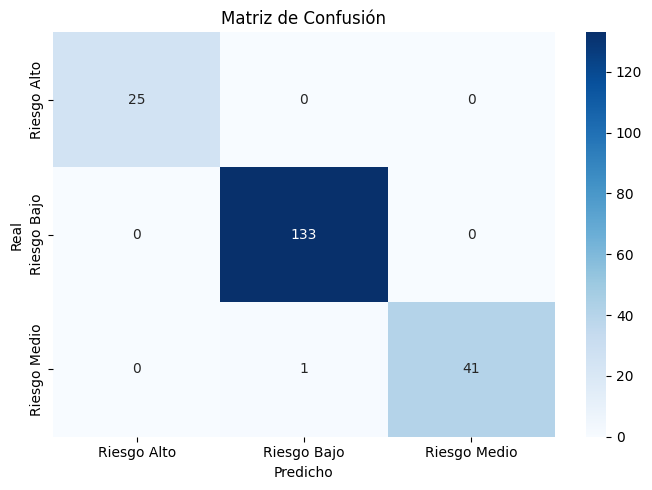

In [60]:
# 11.1 Matriz de Confusión
plt.figure(figsize=(7, 5))
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=model.classes_, yticklabels=model.classes_)
plt.title('Matriz de Confusión')
plt.ylabel('Real')
plt.xlabel('Predicho')
plt.tight_layout()
plt.show()

C:\Users\TEILS\AppData\Local\Temp\ipykernel_9816\1798849659.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feat_importance.values, y=feat_importance.index, palette='viridis')


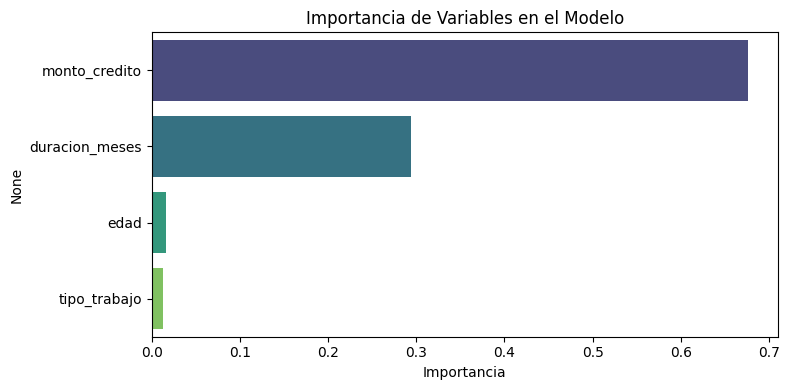


Importancia de variables:
monto_credito     0.676447
duracion_meses    0.293815
edad              0.016645
tipo_trabajo      0.013094
dtype: float64


In [61]:
# 11.2 Importancia de Variables
feat_importance = pd.Series(model.feature_importances_, index=features).sort_values(ascending=False)
 
plt.figure(figsize=(8, 4))
sns.barplot(x=feat_importance.values, y=feat_importance.index, palette='viridis')
plt.title('Importancia de Variables en el Modelo')
plt.xlabel('Importancia')
plt.tight_layout()
plt.show()
 
print("\nImportancia de variables:")
print(feat_importance)

In [64]:
#  12. Ejemplo de prediccion con datos nuevos:
nuevo_cliente = pd.DataFrame([{
    'edad': 35,
    'monto_credito': 5000,
    'duracion_meses': 24,
    'tipo_trabajo': encoders['tipo_trabajo'].transform(['Altamente cualificado'])[0]
    # Cambia 'skilled' por un valor que exista en tu columna tipo_trabajo
}])
 
prediccion = model.predict(nuevo_cliente)
probabilidad = model.predict_proba(nuevo_cliente)
 
print(f"\nPredicción para nuevo cliente: {prediccion[0]}")
print(f"Probabilidades por clase: {dict(zip(model.classes_, probabilidad[0].round(3)))}")
 


Predicción para nuevo cliente: Riesgo Medio
Probabilidades por clase: {'Riesgo Alto': np.float64(0.01), 'Riesgo Bajo': np.float64(0.01), 'Riesgo Medio': np.float64(0.98)}
